In [2]:
import os

# This shows us EXACTLY what folder name Kaggle gave our dataset
print(os.listdir('/kaggle/input/'))

['datasets']


In [3]:
import os

# The folder is called 'datasets' - let's look inside it
print("Inside /kaggle/input/datasets/:")
print(os.listdir('/kaggle/input/datasets/'))

Inside /kaggle/input/datasets/:
['sriharshabsprasad']


In [4]:
import os

# One more level deeper
print("Inside sriharshabsprasad folder:")
print(os.listdir('/kaggle/input/datasets/sriharshabsprasad/'))

Inside sriharshabsprasad folder:
['movielens-dataset-100k-ratings']


In [5]:
import os

# Final level - see all the actual data files
dataset_path = '/kaggle/input/datasets/sriharshabsprasad/movielens-dataset-100k-ratings/'

print("✓ Final dataset path found!")
print(f"  Path: {dataset_path}")
print()
print("Files inside:")
for file in os.listdir(dataset_path):
    size = os.path.getsize(dataset_path + file)
    print(f"  {file}  —  {size/1024:.1f} KB")

✓ Final dataset path found!
  Path: /kaggle/input/datasets/sriharshabsprasad/movielens-dataset-100k-ratings/

Files inside:
  ml-latest-small  —  0.0 KB


In [6]:
import os

# Check inside ml-latest-small folder
final_path = '/kaggle/input/datasets/sriharshabsprasad/movielens-dataset-100k-ratings/ml-latest-small/'

print("Files inside ml-latest-small:")
for file in os.listdir(final_path):
    size = os.path.getsize(final_path + file)
    print(f"  {file}  —  {size/1024:.1f} KB")

Files inside ml-latest-small:
  movies.csv  —  482.8 KB
  ratings.csv  —  2425.5 KB
  README.txt  —  8.1 KB
  tags.csv  —  115.9 KB
  links.csv  —  193.3 KB


In [7]:
import os

# ✓ This is your confirmed correct path - save this!
DATA_PATH = '/kaggle/input/datasets/sriharshabsprasad/movielens-dataset-100k-ratings/ml-latest-small/'

print("✓ Dataset path set successfully!")
print(f"  Path : {DATA_PATH}")
print(f"\nFiles confirmed:")
for file in os.listdir(DATA_PATH):
    size = os.path.getsize(DATA_PATH + file)
    print(f"  ✓ {file}  —  {size/1024:.1f} KB")

✓ Dataset path set successfully!
  Path : /kaggle/input/datasets/sriharshabsprasad/movielens-dataset-100k-ratings/ml-latest-small/

Files confirmed:
  ✓ movies.csv  —  482.8 KB
  ✓ ratings.csv  —  2425.5 KB
  ✓ README.txt  —  8.1 KB
  ✓ tags.csv  —  115.9 KB
  ✓ links.csv  —  193.3 KB


In [8]:
# Core data libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✓ All libraries imported!")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")

✓ All libraries imported!
  pandas  : 2.3.3
  numpy   : 2.0.2


In [9]:
# Load ratings.csv
# Columns: userId, movieId, rating, timestamp
ratings = pd.read_csv(DATA_PATH + 'ratings.csv')

print("✓ Ratings data loaded!")
print(f"  Rows    : {ratings.shape[0]:,}")
print(f"  Columns : {ratings.shape[1]}")
print(f"\nColumn names: {list(ratings.columns)}")
print(f"\nFirst 5 rows:")
ratings.head()

✓ Ratings data loaded!
  Rows    : 100,836
  Columns : 4

Column names: ['userId', 'movieId', 'rating', 'timestamp']

First 5 rows:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [10]:
# Load movies.csv
# Columns: movieId, title, genres
movies = pd.read_csv(DATA_PATH + 'movies.csv')

print("✓ Movies data loaded!")
print(f"  Rows    : {movies.shape[0]:,}")
print(f"  Columns : {movies.shape[1]}")
print(f"\nColumn names: {list(movies.columns)}")
print(f"\nFirst 5 rows:")
movies.head()

✓ Movies data loaded!
  Rows    : 9,742
  Columns : 3

Column names: ['movieId', 'title', 'genres']

First 5 rows:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [11]:
# Load tags.csv
# Columns: userId, movieId, tag, timestamp
tags = pd.read_csv(DATA_PATH + 'tags.csv')

print("✓ Tags data loaded!")
print(f"  Rows    : {tags.shape[0]:,}")
print(f"  Columns : {tags.shape[1]}")
print(f"\nFirst 5 rows:")
tags.head()

✓ Tags data loaded!
  Rows    : 3,683
  Columns : 4

First 5 rows:


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [12]:
# Merge ratings with movies on movieId
df = ratings.merge(movies, on='movieId', how='left')

# Drop timestamp (not needed for our project)
df.drop('timestamp', axis=1, inplace=True)

print("✓ Ratings + Movies merged successfully!")
print(f"  Final shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

✓ Ratings + Movies merged successfully!
  Final shape : 100,836 rows × 5 columns

Column names: ['userId', 'movieId', 'rating', 'title', 'genres']

First 5 rows:


,userId,movieId,rating,title,genres
0,1,1,4.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [13]:
print("=" * 50)
print("        DATASET SUMMARY")
print("=" * 50)

print(f"\n  Total ratings    : {len(df):,}")
print(f"  Unique users     : {df['userId'].nunique():,}")
print(f"  Unique movies    : {df['movieId'].nunique():,}")
print(f"  Rating scale     : {df['rating'].min()} to {df['rating'].max()}")
print(f"  Average rating   : {df['rating'].mean():.2f}")
print(f"  Most common rating : {df['rating'].mode()[0]}")

print(f"\n--- Missing Values ---")
print(df.isnull().sum())

print(f"\n--- Data Types ---")
print(df.dtypes)

print(f"\n--- Rating Distribution ---")
print(df['rating'].value_counts().sort_index())

        DATASET SUMMARY

  Total ratings    : 100,836
  Unique users     : 610
  Unique movies    : 9,724
  Rating scale     : 0.5 to 5.0
  Average rating   : 3.50
  Most common rating : 4.0

--- Missing Values ---
userId     0
movieId    0
rating     0
title      0
genres     0
dtype: int64

--- Data Types ---
userId       int64
movieId      int64
rating     float64
title       object
genres      object
dtype: object

--- Rating Distribution ---
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


In [14]:
# Save the merged data so Step 2 (EDA) can use it directly
df.to_csv('/kaggle/working/merged_data.csv', index=False)

print("✓ Merged data saved successfully!")
print(f"  Saved to : /kaggle/working/merged_data.csv")
print(f"  Rows     : {df.shape[0]:,}")
print(f"  Columns  : {df.shape[1]}")
print(f"\n🎉 Step 1 Complete! Data is ready for Step 2 - EDA")

✓ Merged data saved successfully!
  Saved to : /kaggle/working/merged_data.csv
  Rows     : 100,836
  Columns  : 5

🎉 Step 1 Complete! Data is ready for Step 2 - EDA


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the saved merged data
df = pd.read_csv('/kaggle/working/merged_data.csv')

# Create rating categories (this is the heart of our project!)
def categorize_rating(rating):
    if rating <= 2.5:
        return 'Low'
    elif rating <= 3.5:
        return 'Medium'
    else:
        return 'High'

df['rating_category'] = df['rating'].apply(categorize_rating)

print("✓ Data loaded and categories created!")
print(f"\nCategory distribution:")
print(df['rating_category'].value_counts())
print(f"\nCategory percentages:")
print(df['rating_category'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

✓ Data loaded and categories created!

Category distribution:
rating_category
High      48580
Medium    33183
Low       19073
Name: count, dtype: int64

Category percentages:
rating_category
High      48.2%
Medium    32.9%
Low       18.9%
Name: proportion, dtype: object


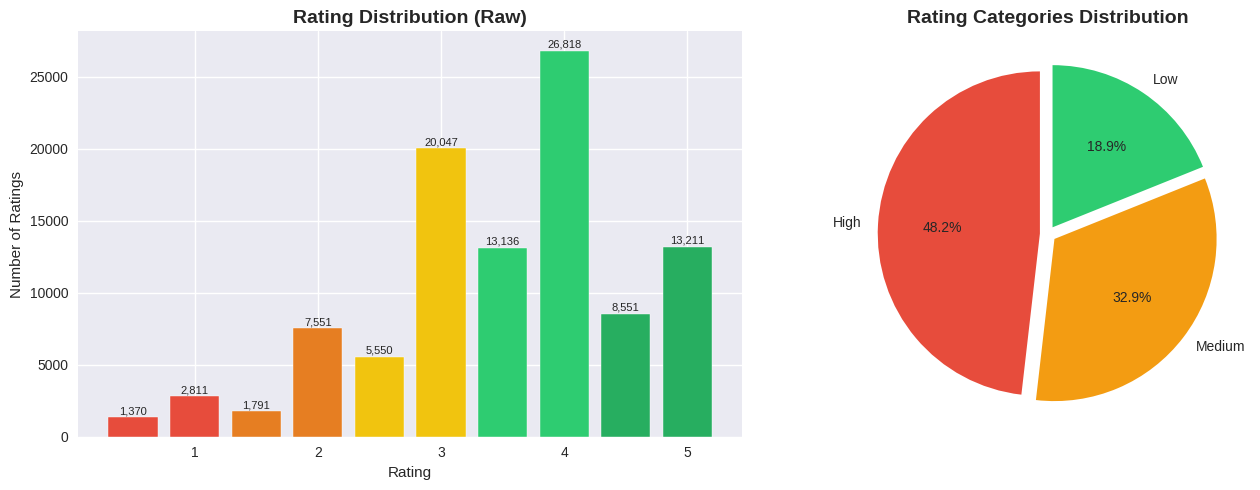

✓ Chart 1 saved!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1a: Raw rating counts
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#e74c3c','#e74c3c','#e67e22','#e67e22',
                   '#f1c40f','#f1c40f','#2ecc71','#2ecc71',
                   '#27ae60','#27ae60'],
            width=0.4, edgecolor='white')
axes[0].set_title('Rating Distribution (Raw)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Ratings')
for i, (x, y) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(x, y + 200, f'{y:,}', ha='center', fontsize=8)

# Chart 1b: Category distribution (pie chart)
category_counts = df['rating_category'].value_counts()
colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[1].pie(category_counts.values,
            labels=category_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            explode=(0.05, 0.05, 0.05))
axes[1].set_title('Rating Categories Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/chart1_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 1 saved!")

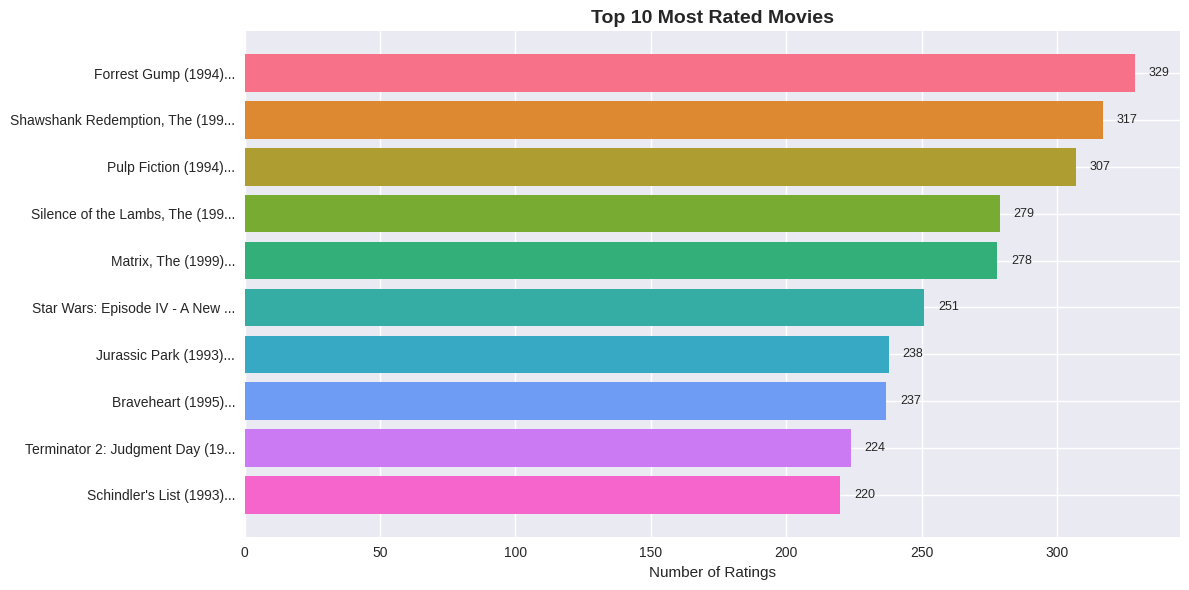

✓ Chart 2 saved!


In [17]:
plt.figure(figsize=(12, 6))

# Count ratings per movie and get top 10
top_movies = df.groupby('title')['rating'].agg(['count', 'mean']).reset_index()
top_movies.columns = ['title', 'num_ratings', 'avg_rating']
top_10 = top_movies.sort_values('num_ratings', ascending=False).head(10)

# Shorten long titles for display
top_10['short_title'] = top_10['title'].str[:30] + '...'

bars = plt.barh(range(10), top_10['num_ratings'].values,
                color=sns.color_palette("husl", 10))
plt.yticks(range(10), top_10['short_title'].values)
plt.xlabel('Number of Ratings')
plt.title('Top 10 Most Rated Movies', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, top_10['num_ratings'].values)):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{count}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/chart2_top_movies.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 2 saved!")

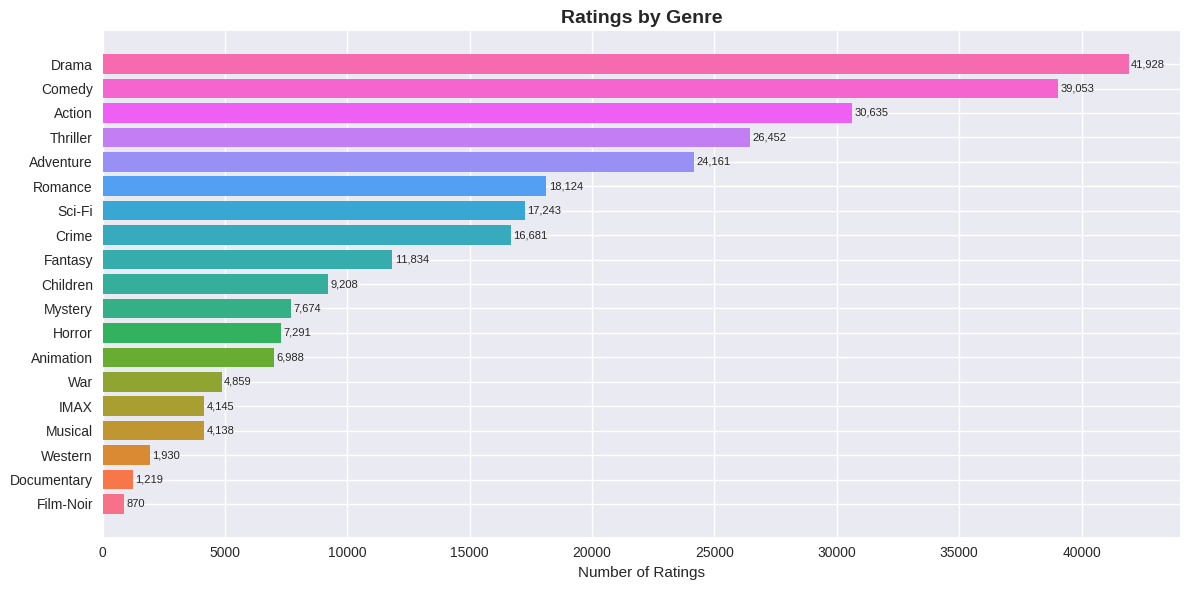

✓ Chart 3 saved!


In [18]:
plt.figure(figsize=(12, 6))

# Split genres and count each genre
genre_counts = {}
for genres in df['genres'].dropna():
    for genre in genres.split('|'):
        genre_counts[genre] = genre_counts.get(genre, 0) + 1

# Remove 'no genres listed'
genre_counts.pop('(no genres listed)', None)

genre_df = pd.DataFrame(list(genre_counts.items()),
                         columns=['genre', 'count'])
genre_df = genre_df.sort_values('count', ascending=True)

colors = sns.color_palette("husl", len(genre_df))
plt.barh(genre_df['genre'], genre_df['count'], color=colors)
plt.xlabel('Number of Ratings')
plt.title('Ratings by Genre', fontsize=14, fontweight='bold')

for i, (genre, count) in enumerate(zip(genre_df['genre'], genre_df['count'])):
    plt.text(count + 100, i, f'{count:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/chart3_genre_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 3 saved!")

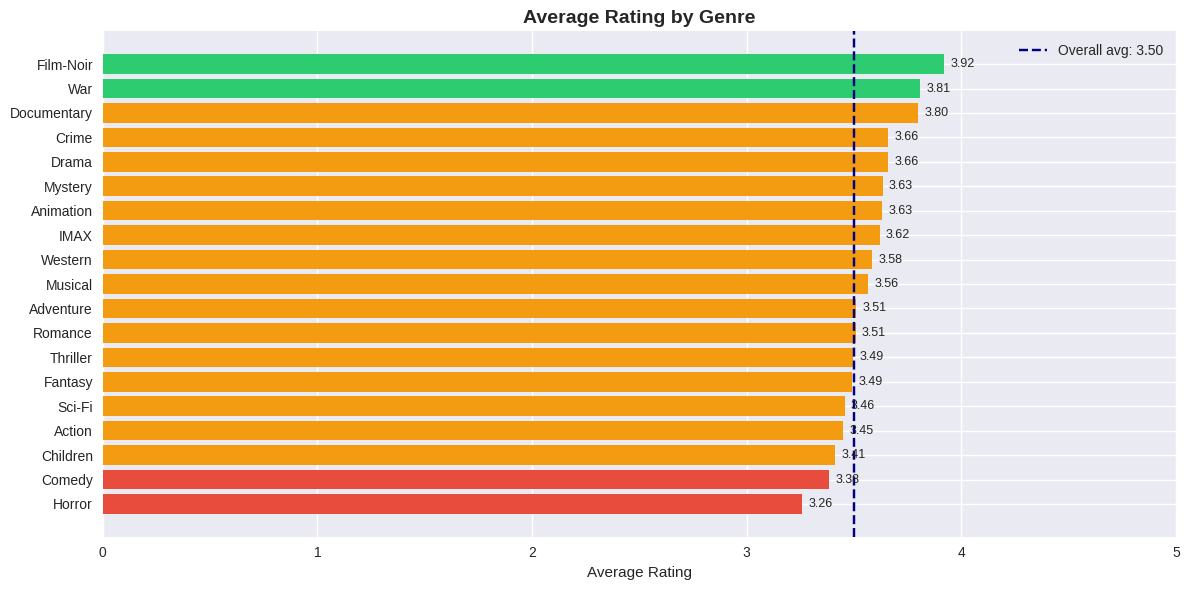

✓ Chart 4 saved!


In [19]:
plt.figure(figsize=(12, 6))

# Calculate average rating per genre
genre_ratings = {}
for _, row in df.iterrows():
    for genre in str(row['genres']).split('|'):
        if genre != '(no genres listed)':
            if genre not in genre_ratings:
                genre_ratings[genre] = []
            genre_ratings[genre].append(row['rating'])

genre_avg = pd.DataFrame({
    'genre': list(genre_ratings.keys()),
    'avg_rating': [np.mean(v) for v in genre_ratings.values()],
    'count': [len(v) for v in genre_ratings.values()]
}).sort_values('avg_rating', ascending=True)

colors = ['#e74c3c' if x < 3.4 else '#f39c12'
          if x < 3.8 else '#2ecc71' for x in genre_avg['avg_rating']]
bars = plt.barh(genre_avg['genre'], genre_avg['avg_rating'], color=colors)
plt.xlabel('Average Rating')
plt.title('Average Rating by Genre', fontsize=14, fontweight='bold')
plt.xlim(0, 5)
plt.axvline(x=df['rating'].mean(), color='navy',
            linestyle='--', label=f'Overall avg: {df["rating"].mean():.2f}')
plt.legend()

for bar, val in zip(bars, genre_avg['avg_rating']):
    plt.text(val + 0.03, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/chart4_genre_avg_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 4 saved!")

In [20]:
print("=" * 50)
print("     STEP 2 - EDA COMPLETE ✅")
print("=" * 50)
print(f"""
Charts created and saved:
  ✓ Chart 1 — Rating distribution + category pie
  ✓ Chart 2 — Top 10 most rated movies
  ✓ Chart 3 — Ratings count by genre
  ✓ Chart 4 — Average rating by genre

Key findings:
  ✓ Most common rating  : 4.0 (positive bias)
  ✓ Average rating      : {df['rating'].mean():.2f}
  ✓ Largest category    : High ({(df['rating_category']=='High').sum():,} ratings)
  ✓ Total genres found  : {len(genre_avg)} genres
  ✓ Categories saved in : df['rating_category']

Next → Step 3: Preprocessing & Feature Engineering
""")

     STEP 2 - EDA COMPLETE ✅

Charts created and saved:
  ✓ Chart 1 — Rating distribution + category pie
  ✓ Chart 2 — Top 10 most rated movies
  ✓ Chart 3 — Ratings count by genre
  ✓ Chart 4 — Average rating by genre

Key findings:
  ✓ Most common rating  : 4.0 (positive bias)
  ✓ Average rating      : 3.50
  ✓ Largest category    : High (48,580 ratings)
  ✓ Total genres found  : 19 genres
  ✓ Categories saved in : df['rating_category']

Next → Step 3: Preprocessing & Feature Engineering



In [21]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load our saved merged data
df = pd.read_csv('/kaggle/working/merged_data.csv')

# Re-create rating categories
def categorize_rating(rating):
    if rating <= 2.5:
        return 'Low'
    elif rating <= 3.5:
        return 'Medium'
    else:
        return 'High'

df['rating_category'] = df['rating'].apply(categorize_rating)

print("✓ Data loaded successfully!")
print(f"  Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst 3 rows:")
df.head(3)

✓ Data loaded successfully!
  Shape : 100,836 rows × 6 columns

First 3 rows:


,userId,movieId,rating,title,genres,rating_category
0,1,1,4.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,High
1,1,3,4.0,Grumpier Old Men (1995),Comedy|Romance,High
2,1,6,4.0,Heat (1995),Action|Crime|Thriller,High


In [22]:
import re

# Movie titles look like: "Toy Story (1995)"
# Let's extract the year as a new feature

def extract_year(title):
    match = re.search(r'\((\d{4})\)', str(title))
    if match:
        return int(match.group(1))
    return None

df['year'] = df['title'].apply(extract_year)

print("✓ Year extracted from titles!")
print(f"\nYear range: {df['year'].min()} to {df['year'].max()}")
print(f"Missing years: {df['year'].isnull().sum()}")
print(f"\nSample:")
df[['title', 'year']].head(5)

✓ Year extracted from titles!

Year range: 1902.0 to 2018.0
Missing years: 18

Sample:


,title,year
0,Toy Story (1995),1995.0
1,Grumpier Old Men (1995),1995.0
2,Heat (1995),1995.0
3,Seven (a.k.a. Se7en) (1995),1995.0
4,"Usual Suspects, The (1995)",1995.0


In [23]:
# Currently genres look like: "Action|Adventure|Sci-Fi"
# We need to split them into separate binary columns
# 1 = movie belongs to that genre, 0 = it doesn't

# Get all unique genres
all_genres = set()
for genres in df['genres'].dropna():
    for genre in genres.split('|'):
        if genre != '(no genres listed)':
            all_genres.add(genre)

all_genres = sorted(list(all_genres))
print(f"✓ Found {len(all_genres)} unique genres:")
print(f"  {all_genres}")

# Create a binary column for each genre
for genre in all_genres:
    df[f'genre_{genre}'] = df['genres'].apply(
        lambda x: 1 if genre in str(x).split('|') else 0
    )

print(f"\n✓ Genre columns created!")
print(f"  New columns added: {len(all_genres)}")
print(f"  Total columns now: {df.shape[1]}")

✓ Found 19 unique genres:
  ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

✓ Genre columns created!
  New columns added: 19
  Total columns now: 26


In [24]:
# For each movie, calculate:
# - How many times it was rated (popularity)
# - Its average rating
# - Standard deviation of its ratings (consistency)

movie_features = df.groupby('movieId').agg(
    movie_rating_count  = ('rating', 'count'),
    movie_avg_rating    = ('rating', 'mean'),
    movie_rating_std    = ('rating', 'std')
).reset_index()

# Fill NaN std (movies with only 1 rating have no std)
movie_features['movie_rating_std'] = movie_features['movie_rating_std'].fillna(0)

# Round to 3 decimal places
movie_features['movie_avg_rating'] = movie_features['movie_avg_rating'].round(3)
movie_features['movie_rating_std']  = movie_features['movie_rating_std'].round(3)

# Merge back into main dataframe
df = df.merge(movie_features, on='movieId', how='left')

print("✓ Movie-level features created!")
print(f"\nNew features added:")
print(f"  movie_rating_count — how popular the movie is")
print(f"  movie_avg_rating   — average rating of the movie")
print(f"  movie_rating_std   — how consistent ratings are")
print(f"\nSample:")
df[['title', 'movie_rating_count',
    'movie_avg_rating', 'movie_rating_std']].drop_duplicates('title').head(5)

✓ Movie-level features created!

New features added:
  movie_rating_count — how popular the movie is
  movie_avg_rating   — average rating of the movie
  movie_rating_std   — how consistent ratings are

Sample:


,title,movie_rating_count,movie_avg_rating,movie_rating_std
0,Toy Story (1995),215,3.921,0.835
1,Grumpier Old Men (1995),52,3.260,1.055
2,Heat (1995),102,3.946,0.817
3,Seven (a.k.a. Se7en) (1995),203,3.975,0.922
4,"Usual Suspects, The (1995)",204,4.238,0.801


In [25]:
# For each user, calculate:
# - How many movies they rated (activity level)
# - Their average rating (are they generous or strict?)
# - Their rating std (how varied are their ratings)

user_features = df.groupby('userId').agg(
    user_rating_count = ('rating', 'count'),
    user_avg_rating   = ('rating', 'mean'),
    user_rating_std   = ('rating', 'std')
).reset_index()

user_features['user_rating_std']  = user_features['user_rating_std'].fillna(0)
user_features['user_avg_rating']  = user_features['user_avg_rating'].round(3)
user_features['user_rating_std']  = user_features['user_rating_std'].round(3)

# Merge back into main dataframe
df = df.merge(user_features, on='userId', how='left')

print("✓ User-level features created!")
print(f"\nNew features added:")
print(f"  user_rating_count — how active the user is")
print(f"  user_avg_rating   — is user generous or strict?")
print(f"  user_rating_std   — how varied their ratings are")
print(f"\nSample:")
df[['userId', 'user_rating_count',
    'user_avg_rating', 'user_rating_std']].drop_duplicates('userId').head(5)

✓ User-level features created!

New features added:
  user_rating_count — how active the user is
  user_avg_rating   — is user generous or strict?
  user_rating_std   — how varied their ratings are

Sample:


,userId,user_rating_count,user_avg_rating,user_rating_std
0,1,232,4.366,0.800
232,2,29,3.948,0.806
261,3,39,2.436,2.091
300,4,216,3.556,1.314
516,5,44,3.636,0.990


In [26]:
# ML models need numbers, not words
# So we convert: Low=0, Medium=1, High=2

label_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['rating_label'] = df['rating_category'].map(label_map)

print("✓ Target label encoded!")
print(f"\nLabel mapping:")
for category, number in label_map.items():
    count = (df['rating_label'] == number).sum()
    print(f"  {category:8s} → {number}  ({count:,} records)")

✓ Target label encoded!

Label mapping:
  Low      → 0  (19,073 records)
  Medium   → 1  (33,183 records)
  High     → 2  (48,580 records)


In [27]:
# Pick all the features we'll feed into our ML models
genre_columns = [col for col in df.columns if col.startswith('genre_')]

feature_columns = (
    ['movie_rating_count', 'movie_avg_rating', 'movie_rating_std',
     'user_rating_count',  'user_avg_rating',  'user_rating_std',
     'year']
    + genre_columns
)

# Create final feature matrix X and target y
X = df[feature_columns].fillna(0)
y = df['rating_label']

print("✓ Feature matrix ready!")
print(f"\n  X shape : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"  y shape : {y.shape[0]:,} labels")
print(f"\nFeature list ({len(feature_columns)} total):")
print(f"  Numerical : movie_rating_count, movie_avg_rating, movie_rating_std,")
print(f"              user_rating_count, user_avg_rating, user_rating_std, year")
print(f"  Genre cols: {len(genre_columns)} genre binary features")

✓ Feature matrix ready!

  X shape : 100,836 rows × 26 features
  y shape : 100,836 labels

Feature list (26 total):
  Numerical : movie_rating_count, movie_avg_rating, movie_rating_std,
              user_rating_count, user_avg_rating, user_rating_std, year
  Genre cols: 19 genre binary features


In [28]:
from sklearn.model_selection import train_test_split

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,       # makes results reproducible
    stratify=y             # keeps same category ratio in both splits
)

print("✓ Data split into train and test sets!")
print(f"\n  Training set   : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test set       : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nCategory balance in training set:")
for label, name in {0:'Low', 1:'Medium', 2:'High'}.items():
    count = (y_train == label).sum()
    pct = count / len(y_train) * 100
    print(f"  {name:8s} : {count:,}  ({pct:.1f}%)")

✓ Data split into train and test sets!

  Training set   : 80,668 rows (80%)
  Test set       : 20,168 rows (20%)

Category balance in training set:
  Low      : 15,258  (18.9%)
  Medium   : 26,546  (32.9%)
  High     : 38,864  (48.2%)


In [29]:
import joblib

# Save the processed dataframe
df.to_csv('/kaggle/working/processed_data.csv', index=False)

# Save train/test splits
X_train.to_csv('/kaggle/working/X_train.csv', index=False)
X_test.to_csv('/kaggle/working/X_test.csv',  index=False)
y_train.to_csv('/kaggle/working/y_train.csv', index=False)
y_test.to_csv('/kaggle/working/y_test.csv',  index=False)

# Save feature column names
import json
with open('/kaggle/working/feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

print("=" * 50)
print("     STEP 3 - PREPROCESSING COMPLETE ✅")
print("=" * 50)
print(f"""
Features engineered:
  ✓ Year extracted from movie titles
  ✓ {len(genre_columns)} genre binary columns created
  ✓ Movie-level stats (count, avg, std)
  ✓ User-level stats  (count, avg, std)
  ✓ Labels encoded    (Low=0, Medium=1, High=2)
  ✓ Train/test split  (80% / 20%)

Files saved:
  ✓ processed_data.csv
  ✓ X_train.csv / X_test.csv
  ✓ y_train.csv / y_test.csv
  ✓ feature_columns.json

Total features for ML : {len(feature_columns)}
Training samples      : {X_train.shape[0]:,}
Test samples          : {X_test.shape[0]:,}

Next → Step 4: Training ML Models! 🤖
""")

     STEP 3 - PREPROCESSING COMPLETE ✅

Features engineered:
  ✓ Year extracted from movie titles
  ✓ 19 genre binary columns created
  ✓ Movie-level stats (count, avg, std)
  ✓ User-level stats  (count, avg, std)
  ✓ Labels encoded    (Low=0, Medium=1, High=2)
  ✓ Train/test split  (80% / 20%)

Files saved:
  ✓ processed_data.csv
  ✓ X_train.csv / X_test.csv
  ✓ y_train.csv / y_test.csv
  ✓ feature_columns.json

Total features for ML : 26
Training samples      : 80,668
Test samples          : 20,168

Next → Step 4: Training ML Models! 🤖



In [30]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

# Load train/test data
X_train = pd.read_csv('/kaggle/working/X_train.csv')
X_test  = pd.read_csv('/kaggle/working/X_test.csv')
y_train = pd.read_csv('/kaggle/working/y_train.csv').squeeze()
y_test  = pd.read_csv('/kaggle/working/y_test.csv').squeeze()

# Load feature columns
with open('/kaggle/working/feature_columns.json', 'r') as f:
    feature_columns = json.load(f)

print("✓ Data loaded for model training!")
print(f"\n  X_train : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"  X_test  : {X_test.shape[0]:,} rows × {X_test.shape[1]} features")
print(f"\nTarget classes:")
print(f"  0 = Low   | 1 = Medium | 2 = High")
print(f"\nClass distribution in training set:")
for label, name in {0:'Low', 1:'Medium', 2:'High'}.items():
    count = (y_train == label).sum()
    print(f"  {name} : {count:,}")

✓ Data loaded for model training!

  X_train : 80,668 rows × 26 features
  X_test  : 20,168 rows × 26 features

Target classes:
  0 = Low   | 1 = Medium | 2 = High

Class distribution in training set:
  Low : 15,258
  Medium : 26,546
  High : 38,864


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import time

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train the model
print("Training Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

end = time.time()

# Evaluate
lr_predictions = lr_model.predict(X_test_scaled)
lr_accuracy    = accuracy_score(y_test, lr_predictions)

print(f"\n✓ Logistic Regression trained in {end-start:.1f} seconds!")
print(f"\n  Accuracy : {lr_accuracy*100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, lr_predictions,
      target_names=['Low', 'Medium', 'High']))

Training Logistic Regression...

✓ Logistic Regression trained in 0.6 seconds!

  Accuracy : 63.94%

Detailed Report:
              precision    recall  f1-score   support

         Low       0.62      0.48      0.54      3815
      Medium       0.55      0.46      0.50      6637
        High       0.69      0.83      0.75      9716

    accuracy                           0.64     20168
   macro avg       0.62      0.59      0.60     20168
weighted avg       0.63      0.64      0.63     20168



In [32]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest (this may take ~30 seconds)...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=15,        # max depth of each tree
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
rf_model.fit(X_train, y_train)

end = time.time()

# Evaluate
rf_predictions = rf_model.predict(X_test)
rf_accuracy    = accuracy_score(y_test, rf_predictions)

print(f"\n✓ Random Forest trained in {end-start:.1f} seconds!")
print(f"\n  Accuracy : {rf_accuracy*100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, rf_predictions,
      target_names=['Low', 'Medium', 'High']))

Training Random Forest (this may take ~30 seconds)...

✓ Random Forest trained in 4.3 seconds!

  Accuracy : 65.61%

Detailed Report:
              precision    recall  f1-score   support

         Low       0.69      0.48      0.56      3815
      Medium       0.56      0.50      0.53      6637
        High       0.70      0.83      0.76      9716

    accuracy                           0.66     20168
   macro avg       0.65      0.60      0.62     20168
weighted avg       0.65      0.66      0.65     20168



In [33]:
from xgboost import XGBClassifier

print("Training XGBoost...")
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

end = time.time()

# Evaluate
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy    = accuracy_score(y_test, xgb_predictions)

print(f"\n✓ XGBoost trained in {end-start:.1f} seconds!")
print(f"\n  Accuracy : {xgb_accuracy*100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, xgb_predictions,
      target_names=['Low', 'Medium', 'High']))

Training XGBoost...

✓ XGBoost trained in 3.4 seconds!

  Accuracy : 66.30%

Detailed Report:
              precision    recall  f1-score   support

         Low       0.68      0.50      0.57      3815
      Medium       0.58      0.52      0.54      6637
        High       0.70      0.83      0.76      9716

    accuracy                           0.66     20168
   macro avg       0.65      0.61      0.63     20168
weighted avg       0.66      0.66      0.65     20168



In [34]:
from sklearn.naive_bayes import GaussianNB

print("Training Naive Bayes...")
start = time.time()

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

end = time.time()

# Evaluate
nb_predictions = nb_model.predict(X_test)
nb_accuracy    = accuracy_score(y_test, nb_predictions)

print(f"\n✓ Naive Bayes trained in {end-start:.1f} seconds!")
print(f"\n  Accuracy : {nb_accuracy*100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, nb_predictions,
      target_names=['Low', 'Medium', 'High']))

Training Naive Bayes...

✓ Naive Bayes trained in 0.0 seconds!

  Accuracy : 52.20%

Detailed Report:
              precision    recall  f1-score   support

         Low       0.37      0.68      0.48      3815
      Medium       0.44      0.34      0.38      6637
        High       0.70      0.59      0.64      9716

    accuracy                           0.52     20168
   macro avg       0.50      0.53      0.50     20168
weighted avg       0.55      0.52      0.52     20168



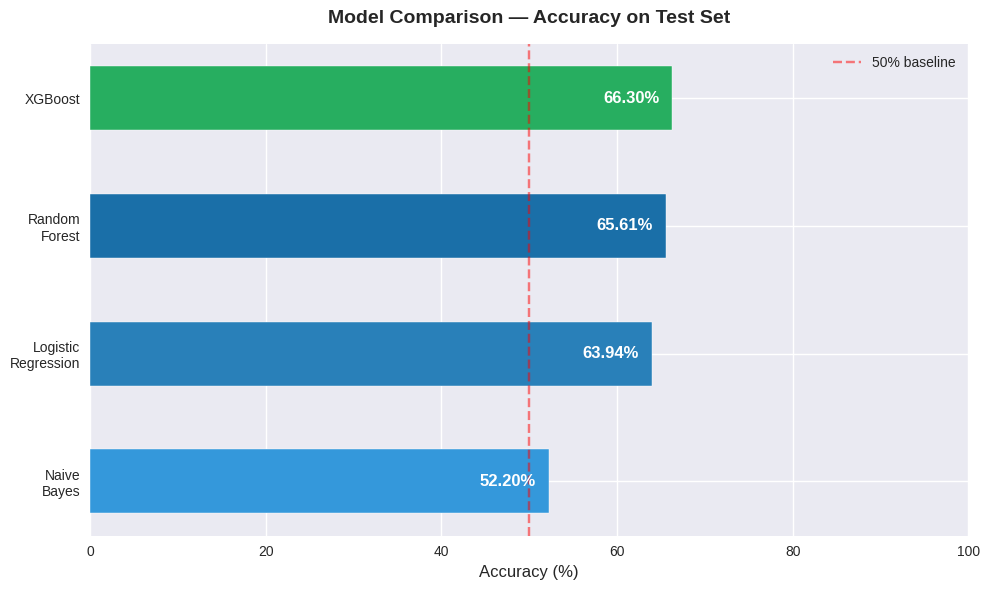

✓ Model comparison chart saved!


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect all results
models = {
    'Logistic\nRegression': lr_accuracy  * 100,
    'Naive\nBayes':         nb_accuracy  * 100,
    'Random\nForest':       rf_accuracy  * 100,
    'XGBoost':              xgb_accuracy * 100,
}

# Sort by accuracy
models = dict(sorted(models.items(), key=lambda x: x[1]))

# Color: best model = green, others = shades of blue
colors = ['#3498db', '#2980b9', '#1a6fa8', '#27ae60']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(list(models.keys()), list(models.values()),
               color=colors, edgecolor='white', height=0.5)

# Add value labels on bars
for bar, val in zip(bars, models.values()):
    ax.text(bar.get_width() - 1.5,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', ha='right',
            color='white', fontweight='bold', fontsize=12)

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Accuracy on Test Set',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 100)
ax.axvline(x=50, color='red', linestyle='--',
           alpha=0.5, label='50% baseline')
ax.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/chart5_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Model comparison chart saved!")

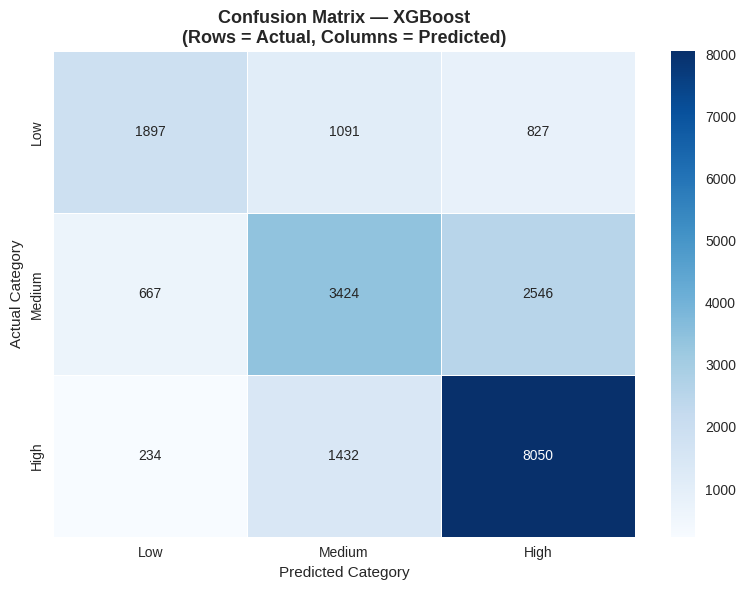

✓ Confusion matrix saved!


In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Find the best model automatically
best_name = max(models, key=models.get).replace('\n', ' ')
best_acc  = max(models.values())

# Use XGBoost predictions for confusion matrix (usually best)
cm = confusion_matrix(y_test, xgb_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'],
            linewidths=0.5)

plt.title('Confusion Matrix — XGBoost\n(Rows = Actual, Columns = Predicted)',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual Category', fontsize=11)
plt.xlabel('Predicted Category', fontsize=11)

plt.tight_layout()
plt.savefig('/kaggle/working/chart6_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Confusion matrix saved!")

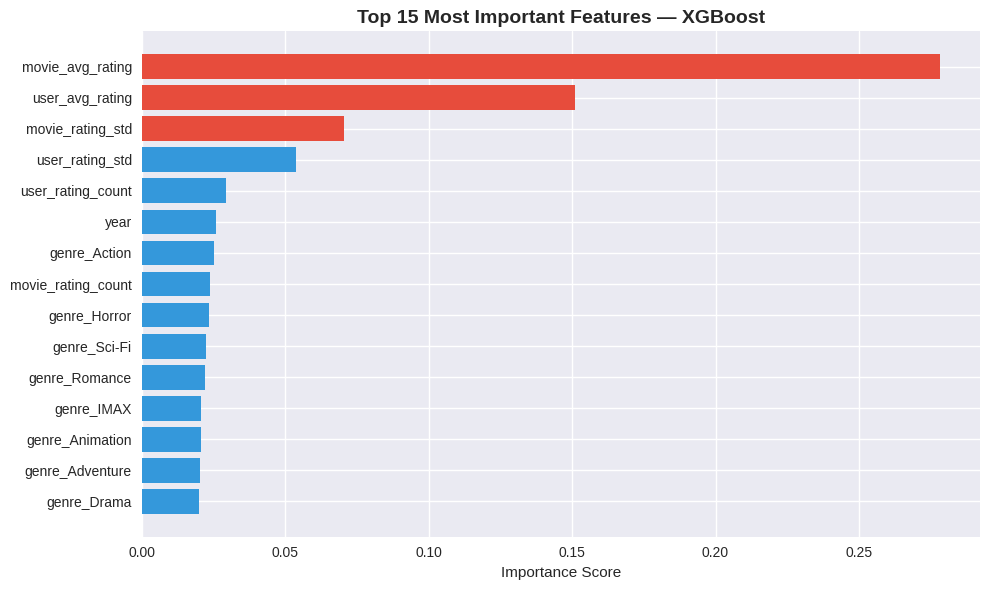

✓ Feature importance chart saved!


In [37]:
# XGBoost gives us feature importance scores
importances = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if i < 3 else '#3498db'
          for i in range(len(importances))]

plt.barh(importances['feature'][::-1],
         importances['importance'][::-1],
         color=colors[::-1])

plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features — XGBoost',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/chart7_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Feature importance chart saved!")

In [38]:
import joblib

# Save all models
joblib.dump(lr_model,  '/kaggle/working/model_logistic.pkl')
joblib.dump(rf_model,  '/kaggle/working/model_randomforest.pkl')
joblib.dump(xgb_model, '/kaggle/working/model_xgboost.pkl')
joblib.dump(nb_model,  '/kaggle/working/model_naivebayes.pkl')
joblib.dump(scaler,    '/kaggle/working/scaler.pkl')

print("=" * 55)
print("     STEP 4 — MODEL TRAINING COMPLETE ✅")
print("=" * 55)
print(f"""
Model Accuracies:
  Naive Bayes          : {nb_accuracy*100:.2f}%
  Logistic Regression  : {lr_accuracy*100:.2f}%
  Random Forest        : {rf_accuracy*100:.2f}%
  XGBoost              : {xgb_accuracy*100:.2f}%

Charts saved:
  ✓ chart5_model_comparison.png
  ✓ chart6_confusion_matrix.png
  ✓ chart7_feature_importance.png

Models saved:
  ✓ model_logistic.pkl
  ✓ model_randomforest.pkl
  ✓ model_xgboost.pkl
  ✓ model_naivebayes.pkl

Next → Step 5: Final Report + GitHub Push! 🚀
""")

     STEP 4 — MODEL TRAINING COMPLETE ✅

Model Accuracies:
  Naive Bayes          : 52.20%
  Logistic Regression  : 63.94%
  Random Forest        : 65.61%
  XGBoost              : 66.30%

Charts saved:
  ✓ chart5_model_comparison.png
  ✓ chart6_confusion_matrix.png
  ✓ chart7_feature_importance.png

Models saved:
  ✓ model_logistic.pkl
  ✓ model_randomforest.pkl
  ✓ model_xgboost.pkl
  ✓ model_naivebayes.pkl

Next → Step 5: Final Report + GitHub Push! 🚀



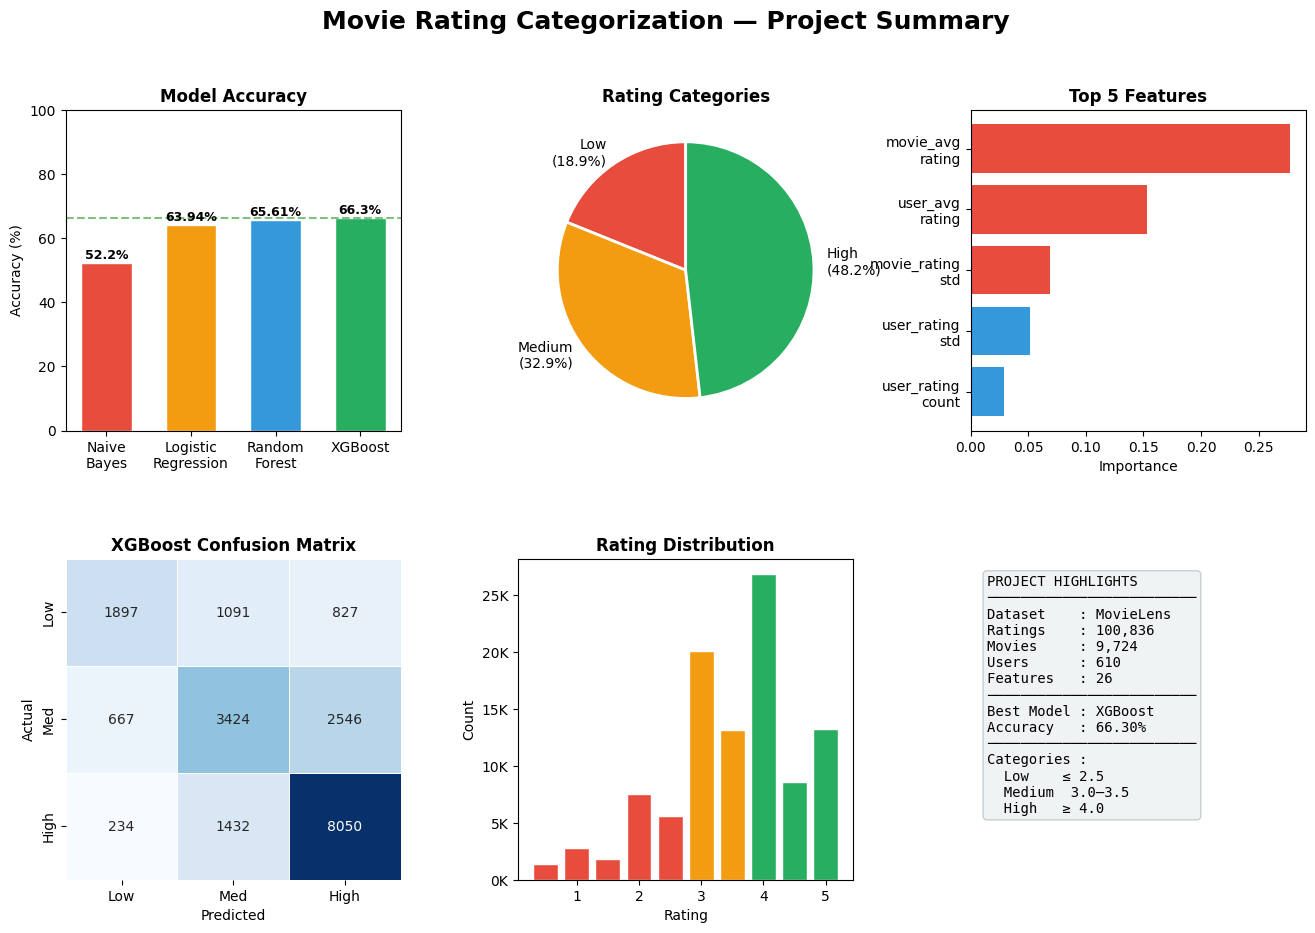

✓ Final summary chart saved!


In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import warnings
warnings.filterwarnings('ignore')

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Movie Rating Categorization — Project Summary',
             fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# --- Chart 1: Model Accuracy Comparison ---
ax1 = fig.add_subplot(gs[0, 0])
model_names  = ['Naive\nBayes', 'Logistic\nRegression',
                'Random\nForest', 'XGBoost']
accuracies   = [52.20, 63.94, 65.61, 66.30]
bar_colors   = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']
bars = ax1.bar(model_names, accuracies, color=bar_colors,
               edgecolor='white', width=0.6)
ax1.set_ylim(0, 100)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Model Accuracy', fontweight='bold')
for bar, val in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontsize=9,
             fontweight='bold')
ax1.axhline(y=66.30, color='green', linestyle='--', alpha=0.5)

# --- Chart 2: Category Distribution Pie ---
ax2 = fig.add_subplot(gs[0, 1])
sizes  = [18.9, 32.9, 48.2]
labels = ['Low\n(18.9%)', 'Medium\n(32.9%)', 'High\n(48.2%)']
colors = ['#e74c3c', '#f39c12', '#27ae60']
ax2.pie(sizes, labels=labels, colors=colors, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Rating Categories', fontweight='bold')

# --- Chart 3: Top 5 Feature Importance ---
ax3 = fig.add_subplot(gs[0, 2])
features    = ['movie_avg\nrating', 'user_avg\nrating',
               'movie_rating\nstd', 'user_rating\nstd',
               'user_rating\ncount']
importances = [0.277, 0.153, 0.069, 0.052, 0.029]
bar_colors3 = ['#e74c3c','#e74c3c','#e74c3c','#3498db','#3498db']
ax3.barh(features[::-1], importances[::-1], color=bar_colors3[::-1])
ax3.set_xlabel('Importance')
ax3.set_title('Top 5 Features', fontweight='bold')

# --- Chart 4: Confusion Matrix ---
ax4 = fig.add_subplot(gs[1, 0])
import seaborn as sns
cm = np.array([[1897, 1091, 827],
               [667,  3424, 2546],
               [234,  1432, 8050]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Low','Med','High'],
            yticklabels=['Low','Med','High'],
            linewidths=0.5, cbar=False)
ax4.set_title('XGBoost Confusion Matrix', fontweight='bold')
ax4.set_ylabel('Actual')
ax4.set_xlabel('Predicted')

# --- Chart 5: Rating Distribution ---
ax5 = fig.add_subplot(gs[1, 1])
ratings = [0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0]
counts  = [1370,2811,1791,7551,5550,20047,13136,26818,8551,13211]
bar_c   = ['#e74c3c']*5 + ['#f39c12']*2 + ['#27ae60']*3
ax5.bar(ratings, counts, width=0.4, color=bar_c, edgecolor='white')
ax5.set_xlabel('Rating')
ax5.set_ylabel('Count')
ax5.set_title('Rating Distribution', fontweight='bold')
ax5.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))

# --- Chart 6: Key Stats Box ---
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
stats_text = (
    "PROJECT HIGHLIGHTS\n"
    "─────────────────────────\n"
    "Dataset    : MovieLens\n"
    "Ratings    : 100,836\n"
    "Movies     : 9,724\n"
    "Users      : 610\n"
    "Features   : 26\n"
    "─────────────────────────\n"
    "Best Model : XGBoost\n"
    "Accuracy   : 66.30%\n"
    "─────────────────────────\n"
    "Categories :\n"
    "  Low    ≤ 2.5\n"
    "  Medium  3.0–3.5\n"
    "  High   ≥ 4.0"
)
ax6.text(0.05, 0.95, stats_text,
         transform=ax6.transAxes,
         fontsize=10, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#ecf0f1',
                   alpha=0.8, edgecolor='#bdc3c7'))

plt.savefig('/kaggle/working/final_summary_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Final summary chart saved!")

In [2]:
print("=" * 60)
print("    MOVIE RATING CATEGORIZATION — COMPLETE SUMMARY")
print("=" * 60)

print("""
DATASET
  Source     : MovieLens Latest Small (Kaggle)
  Ratings    : 100,836
  Movies     : 9,724
  Users      : 610
  Rating range: 0.5 to 5.0

PREPROCESSING
  Features engineered : 26 total
    - Movie stats     : avg rating, rating count, std
    - User stats      : avg rating, rating count, std
    - Genre features  : 19 binary genre columns
    - Year            : extracted from movie title
  Target labels:
    - Low    (≤ 2.5) : 19,073 ratings (18.9%)
    - Medium (3–3.5) : 33,183 ratings (32.9%)
    - High   (≥ 4.0) : 48,580 ratings (48.2%)

MODEL RESULTS
  Naive Bayes          : 52.20%
  Logistic Regression  : 63.94%
  Random Forest        : 65.61%
  XGBoost              : 66.30% ← Best Model

KEY FINDINGS
  1. movie_avg_rating is the strongest predictor (27.7%)
  2. user_avg_rating is second strongest (15.3%)
  3. High ratings are easiest to predict (82.9% recall)
  4. Medium ratings are hardest (boundary between classes)
  5. Drama & Comedy dominate dataset (most-watched genres)
  6. Film-Noir has highest avg rating despite fewest ratings

TOOLS USED
  Python, Pandas, NumPy, Scikit-learn,
  XGBoost, Matplotlib, Seaborn, Kaggle
""")
print("=" * 60)
print("  Project by: Yukesh S")
print("  Platform  : Kaggle Notebooks")
print("=" * 60)

    MOVIE RATING CATEGORIZATION — COMPLETE SUMMARY

DATASET
  Source     : MovieLens Latest Small (Kaggle)
  Ratings    : 100,836
  Movies     : 9,724
  Users      : 610
  Rating range: 0.5 to 5.0

PREPROCESSING
  Features engineered : 26 total
    - Movie stats     : avg rating, rating count, std
    - User stats      : avg rating, rating count, std
    - Genre features  : 19 binary genre columns
    - Year            : extracted from movie title
  Target labels:
    - Low    (≤ 2.5) : 19,073 ratings (18.9%)
    - Medium (3–3.5) : 33,183 ratings (32.9%)
    - High   (≥ 4.0) : 48,580 ratings (48.2%)

MODEL RESULTS
  Naive Bayes          : 52.20%
  Logistic Regression  : 63.94%
  Random Forest        : 65.61%
  XGBoost              : 66.30% ← Best Model

KEY FINDINGS
  1. movie_avg_rating is the strongest predictor (27.7%)
  2. user_avg_rating is second strongest (15.3%)
  3. High ratings are easiest to predict (82.9% recall)
  4. Medium ratings are hardest (boundary between classes)
  